In [1]:
import sys
sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/Users/mariana/Documents/projects/Huawei/tdsurv/lib')


from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.special import expit as sigmoid
from utils import get_targets_and_masks
import pickle

In [41]:
# Borrowed from tdsurv (https://github.com/spotify-research/tdsurv/blob/main/notebooks/random-walk-final.ipynb)
def make_generator(mat, sigma, sigma0, thetas, bias, rng):
    """Sample from a Gauss-Markov process.
    
    Initial state:
    
        x_0 = noise(sigma0)
    
    Transition dynamics:
    
        x_nxt = np.dot(mat, x) + noise(sigma)
        
    Churn probability:
    
        p = sigmoid(np.dot(x, thetas) + bias)
    """
    n_dims = mat.shape[0]
    def gen(n_samples, horizon):
        seqs = np.zeros((n_samples, horizon + 1, n_dims + 1))
        ts = np.zeros(n_samples, dtype=int)
        cs = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            seqs[i, 0] = np.append(sigma0 * rng.normal(size=n_dims), 1)
            ts[i] = 1
            for j in range(0, horizon):
                p = sigmoid(np.dot(seqs[i, j, :-1], thetas) + bias)
                if rng.uniform() < p:
                    break
                ts[i] += 1
                seqs[i, j + 1] = np.append(
                    np.dot(mat, seqs[i, j + 1, :-1]) + sigma * rng.normal(size=n_dims),
                    1,
                )
            if ts[i] > horizon:
                ts[i] = horizon
                cs[i] = True
        tgt_lm, hws_lm, mask_lm = get_targets_and_masks(seqs, ts, cs, landmark=True)
        return (seqs.astype(np.float32), ts, cs, tgt_lm, hws_lm, mask_lm)
    return gen

In [105]:
rng = np.random.default_rng(seed=0)

n_dims = 49
horizon = 99
d = n_dims + 1
H = horizon + 1

# Churn parameters.
thetas = rng.normal(size=n_dims)
bias = -8

# Transition dynamics.
mat = 1.0 * np.eye(n_dims)
sigma = 0.5
sigma0 = 1.0 # Affect results quite a lot


gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
seqs, ts, cs, y, hws, m = gen(n_samples=10000, horizon=horizon)

# rng = np.random.default_rng(seed=42)
# gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
# seqs_v, ts_v, cs_v, y_v, hws_v, m_v = gen(n_samples=2000, horizon=horizon)

In [116]:
cs.sum()

1599

In [117]:
cs.sum()/cs.shape[0]

0.199875

In [108]:
with open("../../SurvanData/bigrw-seqs.pkl", "wb") as f:
    pickle.dump({
        "seqs": seqs,
        "cs": cs,
        "ts": ts,
        "target": y,
        "h_ws": hws,
        "mask": m
    }, f)

In [163]:
config_path = '../configs/config_bigrw.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [164]:
config

{'dataset_name': 'big_rw',
 'axis': 2,
 'batch_size': 128,
 'learning_rate': 0.05,
 'log_interval': 1000,
 'weight_decay': 0.01,
 'num_epochs': 300,
 'output_file': '/Users/mariana/Documents/projects/Huawei/Results/{}/',
 'landmark': True,
 'target_lr': 0.01,
 'arch': {'type': 'transformer',
  'arch_kwargs': {'hidden_size': 16,
   'seq_len': 100,
   'output_dim': 8,
   'num_layers': 1,
   'dropout': 0.2}},
 'preprocessed_data': False,
 'dataset_kwargs': {'horizon': 100,
  'data_path': '/Users/mariana/Documents/projects/Huawei/SurvanData/bigrw-seqs.pkl'},
 'lambda_': 0.0,
 'num_steps': 5,
 'verbose': True}

In [165]:
# config['landmark'] = True
config['num_epochs'] = 500
config['lambda_'] = 0.0
config['target_lr'] = 0.01
# model = SA(config, seed=1)
model = DeepLambdaSA(config, seed=2)

In [166]:
model.data['seqs'].shape

(10000, 100, 50)

In [167]:
train_gen, test_gen = model.get_train_test(test_size=.95)
loss = model.train(train_gen)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 500/500 [04:12<00:00,  1.98it/s]


In [186]:
model.config.num_epochs = 100
loss = model.train(train_gen)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:46<00:00,  2.15it/s]


In [187]:
train_gen.X.shape

(500, 100, 50)

In [188]:
train_gen.ts.sum()

22221

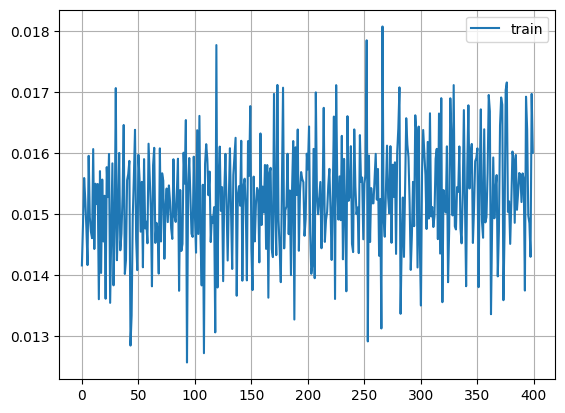

In [189]:
plt.plot(loss, label='train')
# plt.plot(loss[1], label='test')
plt.legend()
plt.grid()

In [190]:
seqs = train_gen.X
ts = train_gen.ts
cs = train_gen.cs
y = train_gen.y

scores = model.scores(seqs, q=0.0)
concordance_index(scores, ts, cs)

0.7816832442007017

In [191]:
model.state.params['linear']['b'].sum()

Array(-119.310005, dtype=float32)

In [192]:
seqs.sum()

22300.168

In [193]:
scores.sum()

Array(5.613355e-18, dtype=float32)

In [194]:
seqs_t = test_gen.X
ts_t = test_gen.ts
cs_t = test_gen.cs
y_t = test_gen.y

scores = model.scores(seqs_t, q=0.0)
concordance_index(scores, ts_t, cs_t)

0.7770200796435441

In [14]:
ts.max()

99

In [93]:
cs.sum()/len(cs)

0.182

In [195]:
100 + 7.95 + 14.85 + 14

136.8